### Generative Adversarial Network
In Lab 3-2, you will explore the practical application of Conditional Generative Adversarial Networks (cGANs). You can play with the model and convert input sketches or uploaded sketch image into painterly images. It is actually synthesizing new pixels (e.g.textures, shadows, materials, etc.) based on the geometric constraints of your lines.

In [1]:
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix
%cd pytorch-CycleGAN-and-pix2pix
!pip install dominate visdom opencv-python

import os, cv2, base64
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files, output
from IPython.display import HTML, display

# Load pre-trained CGAN model (pix2pix) edge2shoes
MODEL_NAME = 'edges2shoes'
DATAROOT = './datasets/my_custom_sketch'

!bash ./scripts/download_pix2pix_model.sh {MODEL_NAME}

Cloning into 'pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2619, done.
remote: Total 2619 (delta 0), reused 0 (delta 0), pack-reused 2619 (from 1)
Receiving objects: 100% (2619/2619), 8.24 MiB | 10.46 MiB/s, done.
Resolving deltas: 100% (1654/1654), done.
/content/pytorch-CycleGAN-and-pix2pix
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for visdom: filename=visdom-0.2.4-py3-none-any.whl size=1408195 sha256=0b9e57fca743e1215a60bd8e6d00201938a801ca76c8aabea15b1e59c4c4829b
  Stored in directory: /root/.cache/pip/wheels/37/6c/38/64eeaa310e325aacda723e6df1f79ab5e9f31ba195264e04a8
Successfully built visdom
Note: available models are edges2shoes, sat2map, map2sat, facades_label2photo, and day2night
Specified [edges2shoes]
for details.

--2026-04-15 19:42:24--  http://efrosgans.eecs.berkeley.edu/pix2pix/models-pytorch/edges2shoes.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.

/content/pytorch-CycleGAN-and-pix2pix


Generating...It might take a few seconds to show the result.


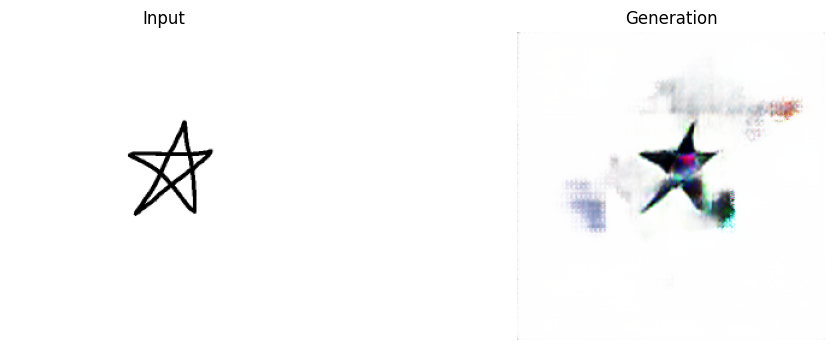

In [3]:
# Path setup
%cd /content/pytorch-CycleGAN-and-pix2pix

dataroot = '/content/pytorch-CycleGAN-and-pix2pix/datasets/my_custom_sketch'
test_dir = os.path.join(dataroot, 'test')
os.makedirs(test_dir, exist_ok=True)


# UI for user to draw sketch on canvas or upload image for generation
canvas_html = """
<div style="border: 1px solid #ccc; padding: 20px; width: 600px; text-align: center; background-color: #f9f9f9; margin: auto; border-radius: 10px; font-family: sans-serif;">
    <h3 style="color: black;">Sketch or Upload</h3>
    <canvas id="main_canvas" width="512" height="512"
        style="border:2px solid black; background:white; cursor:crosshair;"></canvas>

    <br><br>

    <button id="clear_btn">Clear</button>
    <button id="upload_btn">Upload</button>
    <input type="file" id="file_input" accept="image/*" style="display:none;">

    <br><br>

    <button id="done_btn" style="background:green;color:white;padding:10px 20px;">
        Generate
    </button>
</div>

<script>
let canvas = document.getElementById("main_canvas");
let ctx = canvas.getContext("2d");

ctx.fillStyle = "white";
ctx.fillRect(0,0,512,512);

ctx.strokeStyle = "black";
ctx.lineWidth = 6;   // thicker brush for larger canvas
ctx.lineCap = "round";

let drawing = false;

canvas.onmousedown = e => {
    drawing = true;
    ctx.beginPath();
    ctx.moveTo(e.offsetX, e.offsetY);
};

canvas.onmousemove = e => {
    if(drawing){
        ctx.lineTo(e.offsetX, e.offsetY);
        ctx.stroke();
    }
};

canvas.onmouseup = () => drawing = false;

document.getElementById("clear_btn").onclick = () => {
    ctx.fillRect(0,0,512,512);
};

let fileInput = document.getElementById("file_input");

document.getElementById("upload_btn").onclick = () => fileInput.click();

fileInput.onchange = e => {
    let reader = new FileReader();
    reader.onload = event => {
        let img = new Image();
        img.onload = () => {
            ctx.fillRect(0,0,512,512);
            ctx.drawImage(img, 0, 0, 512, 512);
        };
        img.src = event.target.result;
    };
    reader.readAsDataURL(e.target.files[0]);
};

var resolveData;
var data = new Promise(resolve => { resolveData = resolve; });

document.getElementById("done_btn").onclick = () => {
    resolveData(canvas.toDataURL("image/png"));
};
</script>
"""

def main():
    # Display canvas UI
    display(HTML(canvas_html))

    # Canvas output
    data_url = output.eval_js("data")

    try:
        result_path = '/content/pytorch-CycleGAN-and-pix2pix/results/edges2shoes_pretrained/test_latest/images/custom_input_A_fake.png'
        if os.path.exists(result_path):
            os.remove(result_path)

        # Decode base64 canvas image into OpenCV format
        header, encoded = data_url.split(",", 1)
        binary = base64.b64decode(encoded)
        img = cv2.imdecode(np.frombuffer(binary, np.uint8), cv2.IMREAD_COLOR)

        # Resize input to match Pix2Pix's training resolution (256x256)
        img_resized = cv2.resize(img, (256, 256))

        # Save input image in Pix2Pix's expected dataset structure
        input_path = os.path.join(test_dir, 'custom_input_A.png')
        cv2.imwrite(input_path, img_resized)

        print("Generating...It might take a few seconds to show the result.")

        # Run pretrained Pix2Pix model for sketch-to-image translation
        !python3 test.py \
            --dataroot {dataroot} \
            --name edges2shoes_pretrained \
            --model test \
            --netG unet_256 \
            --direction AtoB \
            --dataset_mode single \
            --norm batch \
            --num_test 1 > /dev/null 2>&1

        # Visualization
        if os.path.exists(result_path):
            plt.figure(figsize=(12,4))

            # Input
            plt.subplot(1,2,1)
            plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
            plt.title("Input")
            plt.axis('off')

            # Generation
            plt.subplot(1,2,2)
            plt.imshow(Image.open(result_path))
            plt.title("Generation")
            plt.axis('off')

            plt.show()

        else:
            print("No output generated.")

    except Exception as e:
        print("Error:", e)

# Run the pipeline
main()

In [ ]:
# Path setup
%cd /content/pytorch-CycleGAN-and-pix2pix

import os, io, base64, cv2, numpy as np
from PIL import Image
from IPython.display import HTML, display
from google.colab import output

dataroot = '/content/pytorch-CycleGAN-and-pix2pix/datasets/my_custom_sketch'
test_dir = os.path.join(dataroot, 'test')
os.makedirs(test_dir, exist_ok=True)

canvas_html = """
<div style="
    display:flex;
    gap:24px;
    align-items:flex-start;
    justify-content:center;
    font-family:sans-serif;
    max-width:1200px;
    margin:auto;
">
    <!-- Left side: canvas -->
    <div style="
        border: 1px solid #ccc;
        padding: 20px;
        width: 600px;
        text-align: center;
        background-color: #f9f9f9;
        border-radius: 10px;
    ">
        <h3 style="color:black; margin-top:0;">Sketch or Upload</h3>

        <canvas id="main_canvas" width="512" height="512"
            style="border:2px solid black; background:white; cursor:crosshair;"></canvas>

        <br><br>

        <button id="clear_btn">Clear</button>
        <button id="upload_btn">Upload</button>
        <input type="file" id="file_input" accept="image/*" style="display:none;">

        <br><br>

        <button id="done_btn" style="background:green;color:white;padding:10px 20px;">
            Generate
        </button>

        <p id="status_text" style="color:#444; margin-top:12px;"></p>
    </div>

    <!-- Right side: preview -->
    <div id="preview_panel" style="
        width: 560px;
        min-height: 620px;
        border: 1px solid #ccc;
        padding: 20px;
        background: #ffffff;
        border-radius: 10px;
        box-sizing:border-box;
    ">
        <h3 style="margin-top:0;">Preview</h3>
        <div id="preview_content" style="
            color:#666;
            display:flex;
            align-items:center;
            justify-content:center;
            min-height:540px;
            text-align:center;
        ">
            Nothing generated yet.
        </div>
    </div>
</div>

<script>
(function() {
    const canvas = document.getElementById("main_canvas");
    const ctx = canvas.getContext("2d");
    const fileInput = document.getElementById("file_input");
    const statusText = document.getElementById("status_text");
    const previewContent = document.getElementById("preview_content");

    window.clearCanvas = function() {
        ctx.fillStyle = "white";
        ctx.fillRect(0, 0, 512, 512);
    };

    window.setCanvasStatus = function(msg) {
        statusText.textContent = msg;
    };

    window.clearPreview = function() {
        previewContent.innerHTML = `
            <div style="
                color:#666;
                display:flex;
                align-items:center;
                justify-content:center;
                min-height:540px;
                text-align:center;
                width:100%;
            ">
                Nothing generated yet.
            </div>
        `;
    };

    window.setPreviewImages = function(inputDataUrl, outputDataUrl) {
        previewContent.innerHTML = `
            <div style="width:100%;">
                <div style="display:grid; grid-template-columns: 1fr 1fr; gap:20px; align-items:start;">
                    <div>
                        <div style="font-weight:bold; margin-bottom:10px; text-align:center;">Input</div>
                        <img src="${inputDataUrl}" style="width:100%; border:1px solid #ddd; border-radius:8px; background:white;">
                    </div>
                    <div>
                        <div style="font-weight:bold; margin-bottom:10px; text-align:center;">Generation</div>
                        <img src="${outputDataUrl}" style="width:100%; border:1px solid #ddd; border-radius:8px; background:white;">
                    </div>
                </div>
            </div>
        `;
    };

    window.getCanvasImage = function() {
        return new Promise(resolve => {
            const btn = document.getElementById("done_btn");

            function handler() {
                btn.removeEventListener("click", handler);
                resolve(canvas.toDataURL("image/png"));
            }

            btn.addEventListener("click", handler, { once: true });
        });
    };

    clearCanvas();
    clearPreview();
    setCanvasStatus("Draw or upload, then click Generate.");

    ctx.strokeStyle = "black";
    ctx.lineWidth = 6;
    ctx.lineCap = "round";

    let drawing = false;

    canvas.onmousedown = e => {
        drawing = true;
        ctx.beginPath();
        ctx.moveTo(e.offsetX, e.offsetY);
    };

    canvas.onmousemove = e => {
        if (drawing) {
            ctx.lineTo(e.offsetX, e.offsetY);
            ctx.stroke();
        }
    };

    canvas.onmouseup = () => drawing = false;
    canvas.onmouseleave = () => drawing = false;

    document.getElementById("clear_btn").onclick = () => {
        clearCanvas();
        setCanvasStatus("Canvas cleared.");
    };

    document.getElementById("upload_btn").onclick = () => fileInput.click();

    fileInput.onchange = e => {
        if (!e.target.files.length) return;

        const reader = new FileReader();
        reader.onload = event => {
            const img = new Image();
            img.onload = () => {
                clearCanvas();
                ctx.drawImage(img, 0, 0, 512, 512);
                setCanvasStatus("Image loaded. Click Generate.");
            };
            img.src = event.target.result;
        };
        reader.readAsDataURL(e.target.files[0]);
    };
})();
</script>
"""

def np_to_data_url_rgb(img_rgb):
    ok, buf = cv2.imencode(".png", cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
    if not ok:
        raise ValueError("Failed to encode RGB image.")
    b64 = base64.b64encode(buf.tobytes()).decode("utf-8")
    return f"data:image/png;base64,{b64}"

def pil_to_data_url(pil_img):
    bio = io.BytesIO()
    pil_img.save(bio, format="PNG")
    b64 = base64.b64encode(bio.getvalue()).decode("utf-8")
    return f"data:image/png;base64,{b64}"

def run_generation_once(data_url):
    result_path = '/content/pytorch-CycleGAN-and-pix2pix/results/edges2shoes_pretrained/test_latest/images/custom_input_A_fake.png'
    if os.path.exists(result_path):
        os.remove(result_path)

    header, encoded = data_url.split(",", 1)
    binary = base64.b64decode(encoded)
    img = cv2.imdecode(np.frombuffer(binary, np.uint8), cv2.IMREAD_COLOR)

    if img is None:
        raise ValueError("Could not decode canvas image.")

    img_resized = cv2.resize(img, (256, 256))

    input_path = os.path.join(test_dir, 'custom_input_A.png')
    cv2.imwrite(input_path, img_resized)

    !python3 test.py \
        --dataroot {dataroot} \
        --name edges2shoes_pretrained \
        --model test \
        --netG unet_256 \
        --direction AtoB \
        --dataset_mode single \
        --norm batch \
        --num_test 1 > /dev/null 2>&1

    if not os.path.exists(result_path):
        raise FileNotFoundError("No output generated.")

    input_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    output_pil = Image.open(result_path).convert("RGB")

    return input_rgb, output_pil

def main_loop():
    display(HTML(canvas_html))

    round_num = 1
    while True:
        try:
            output.eval_js(f"setCanvasStatus('Round {round_num}: draw or upload, then click Generate.')")

            data_url = output.eval_js("getCanvasImage()")

            # remove previous result immediately when a new generate starts
            output.eval_js("clearPreview()")
            output.eval_js("setCanvasStatus('Generating...')")

            print(f"Round {round_num}: Generating...")

            input_rgb, output_pil = run_generation_once(data_url)

            input_url = np_to_data_url_rgb(input_rgb)
            output_url = pil_to_data_url(output_pil)

            # show result in side panel
            output.eval_js(f"setPreviewImages({input_url!r}, {output_url!r})")

            # clear drawing area for next round
            output.eval_js("clearCanvas()")
            output.eval_js(f"setCanvasStatus('Done. Canvas cleared for next round.')")

            round_num += 1

        except KeyboardInterrupt:
            output.eval_js("setCanvasStatus('Stopped.')")
            print("\\nStopped by user.")
            break
        except Exception as e:
            output.eval_js(f"setCanvasStatus('Error: {str(e)}')")
            print("Error:", e)

main_loop()

/content/pytorch-CycleGAN-and-pix2pix


Round 1: Generating...
Round 2: Generating...
